# Velocity from gravity-free acceleration

This is the final goal of the pipeline. 

Velocity/speed satisfies the following equation:
$$
\frac{d\mathbf{v}}{dt} = \mathbf{a}(t)
$$
One could try to view this problem in two (related) ways: as an ODE (ordinary differential equation) or as an integration problem. 

Viewing it as an ODE, there are some issues. Most (if not all) methods (Runge-Kutta, multistep) assume an available function of the independent and dependent variables that can be evaluated at different places. This isn't my case: I only have measurements, and I don't have a physical models of calisthenics exercises either. Trying to apply ODE methods anyway would necessarily need some form of curve fitting (e.g. regression, splines) prior to actually running the ODE method itself. This is obviously not viable for a device that has to run real-time on constrainted resources.   

Viewing it as an integration problem, applying the fundamental theorem of calculus, we have:

$$
\int_{t_i}^{t_i+1} d\mathbf{v} = \int_{t_i}^{t_i+1} \mathbf{a}(t) dt \newline
v_{x, t_i+1} = v_{x, t_i} + \int_{t_i}^{t_i+1} a_x(t) dt \newline
v_{y, t_i+1} = v_{y, t_i} + \int_{t_i}^{t_i+1} a_y(t) dt \newline
v_{z, t_i+1} = v_{z, t_i} + \int_{t_i}^{t_i+1} a_z(t) dt \newline
$$
This is a much simpler problem, since for $\mathbf{a}(t)$ I can just apply well-known numerical integration formulas (Newton-Cotes, Adams-Moulton). The best method is the one that gives the best results with the least computational cost.

Sources:
* [Numerical methods for engineers](../../docs/misc/Numerical%20Methods%20for%20Engineers%20(7ed)%20-%20Chapra,%20Canale.pdf). Chapters 21, 25, 26.

## Setup

In [1]:
from signal_utils import IMUSampleReader, IMUStationaryChecker
from scipy import integrate, stats
import numpy as np
import matplotlib.pyplot as plt

SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

stationaryCaptures = [
    "../4-gravityRemoval/output/neg-x-up-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-x-up-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-y-up-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-y-up-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/neg-z-up-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pos-z-up-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
]

simpleRotationsCaptures = [
    "../4-gravityRemoval/output/rot-x-hw-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/rot-y-hw-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/rot-z-hw-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
]

exerciseCaptures = [
    "../4-gravityRemoval/output/dips-1-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/dips-2-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/dips-3-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pull-ups-1-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pull-ups-2-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/pull-ups-3-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/90-deg-push-ups-1-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
    "../4-gravityRemoval/output/90-deg-push-ups-2-calib-affine-a-online-w-or-compl-g-free-rot-mat.csv",
]


rawStationaryCaptures = [
    "../1-calibration/capture/pos-x-up.csv",
    "../1-calibration/capture/neg-x-up.csv",
    "../1-calibration/capture/pos-y-up.csv",
    "../1-calibration/capture/neg-y-up.csv",
    "../1-calibration/capture/pos-z-up.csv",
    "../1-calibration/capture/neg-z-up.csv",
]
stationaryChecker = IMUStationaryChecker()
stationaryChecker.computeTolerances(rawStationaryCaptures)

reader = IMUSampleReader()


def cumulativeEuler(dy, x, dx):
    result = np.zeros_like(dy)
    for i in range(1, len(dy)):
        result[i] = result[i - 1] + dy[i - 1] * dx
    return result


def cumulativeClosedAdams3(dy, x, dx):
    result = np.zeros_like(dy)
    result[1] = (dy[0] + dy[1]) * dx / 2  # Trapezoid rule for the first step
    for i in range(2, len(dy)):
        result[i] = result[i - 1] + (dx / 12) * (5 * dy[i] + 8 * dy[i - 1] - dy[i - 2])
    return result


def computeErrors(trueValues, estimatedValues):
    errors = trueValues - estimatedValues
    rmse = np.sqrt(np.mean(errors**2))
    return (errors, rmse)


def plotODESolutions(axis, title, x, dx, x0, y, dy, y0):
    eulerSol = y0 + cumulativeEuler(dy, x=x, dx=dx)
    trapSol = y0 + integrate.cumulative_trapezoid(dy, x=x, dx=dx, initial=0)
    adams3Sol = y0 + cumulativeClosedAdams3(dy, x=x, dx=dx)
    simpsonSol = y0 + integrate.cumulative_simpson(dy, x=x, dx=dx, initial=0)

    errorsEuler, rmsEuler = computeErrors(y, eulerSol)
    errorsTrap, rmsTrap = computeErrors(y, trapSol)
    errorsAdams3, rmsAdams3 = computeErrors(y, adams3Sol)
    errorsSimpson, rmsSimpson = computeErrors(y, simpsonSol)

    axis.set_title(title)
    axis.plot(x, y, label="Analytical", color="red")
    axis.plot(
        x,
        eulerSol,
        label=f"Euler (RMSE={rmsEuler:.2e}, maxE={np.max(errorsEuler):.2e})",
        color="blue",
    )
    axis.plot(
        x,
        trapSol,
        label=f"Trapezoid (RMSE={rmsTrap:.2e}, maxE={np.max(errorsTrap):.2e})",
        color="green",
    )
    axis.plot(
        x,
        adams3Sol,
        label=f"Adams 3 (RMSE={rmsAdams3:.2e}, maxE={np.max(errorsAdams3):.2e})",
        color="purple",
    )
    axis.plot(
        x,
        simpsonSol,
        label=f"Simpson (RMSE={rmsSimpson:.2e}, maxE={np.max(errorsSimpson):.2e})",
        color="orange",
    )
    axis.legend(fontsize=8)
    axis.grid()

Acceleration norms:	Mean = 9.890416
	Stdev = 0.251631
	Stationary tol = 1.258153
Gyroscope norms: 	Stdev = 2.328577
	Stationary tol = 6.985731


## Simple ODE with known solution
*Equation*: 
$\frac{dy}{dx} = -2x^3 + 12x^2 -20x+8.5, \text{ with } y(0) = 1$

*Conclusion*: 
* Euler is just bad ($O(h)$). It would only work well with very small step sizes and small integration windows. Don't use it if possible.
* The other ones tend to cluster together: Simpson ($O(h^4)$) is better than Adams3 ($O(h^3)$), which in turn is better than Trapezoid ($O(h^2)$).
* On the device, Simpson would need a different implementation. Samples come as a stream, and only one is processed at a time. The solution would need to be provided every two samples, and I would need to be careful of not integrating the same sample twice. Adams-Moulton formulas are a better fit, since they use previous points to fit a polynomial but only integrate on the last interval.
* Higher order polynomials are probably not worth it.

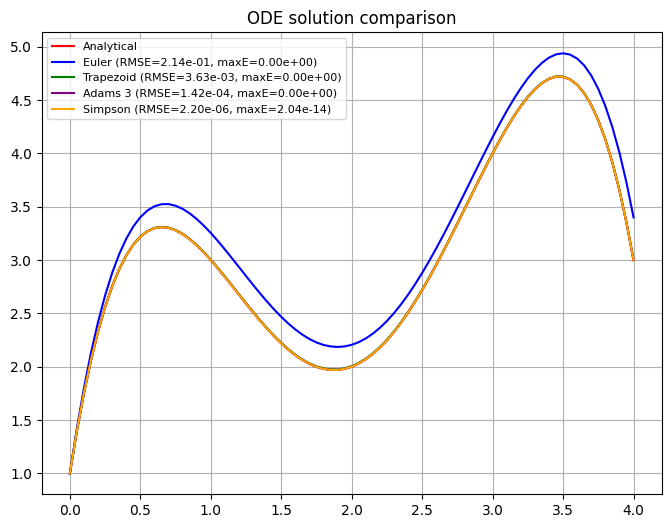

In [2]:
lowerBound = 0
upperBound = 4
dt = 0.05
t = np.arange(lowerBound, upperBound + dt, dt)
a = -2 * t**3 + 12 * t**2 - 20 * t + 8.5
x0 = 0
y0 = 1
v = -0.5 * t**4 + 4 * t**3 - 10 * t**2 + 8.5 * t + 1

fig, axes = plt.subplots(figsize=(8, 6))
plotODESolutions(axes, "ODE solution comparison", t, dt, x0, v, a, y0)
plt.show()

## ODE with various error sources

**General conclusion** (see below for details): 

The more imperfect the input is, the less the integration method or theoretical order matters. The only concession is not to choose Euler if possible, which is the only one that is consistently worse than the others. Focus more on mitigating noise, bias, drift and sampling jitter. 

**Choosen method**:

Trapezoid. The cheapest of the "good" ones, streaming-friendly.

### Noise

Normally distributed noise is chosen because it's the most common type. As a stress-test another, more pathological distribution (e.g. Cauchy) could be tried out later. 

*Conclusion*:

The more the signal is buried in noise, the less the integration method matters. However, Euler still performs worse than the others. Increasing the step size tends to help.

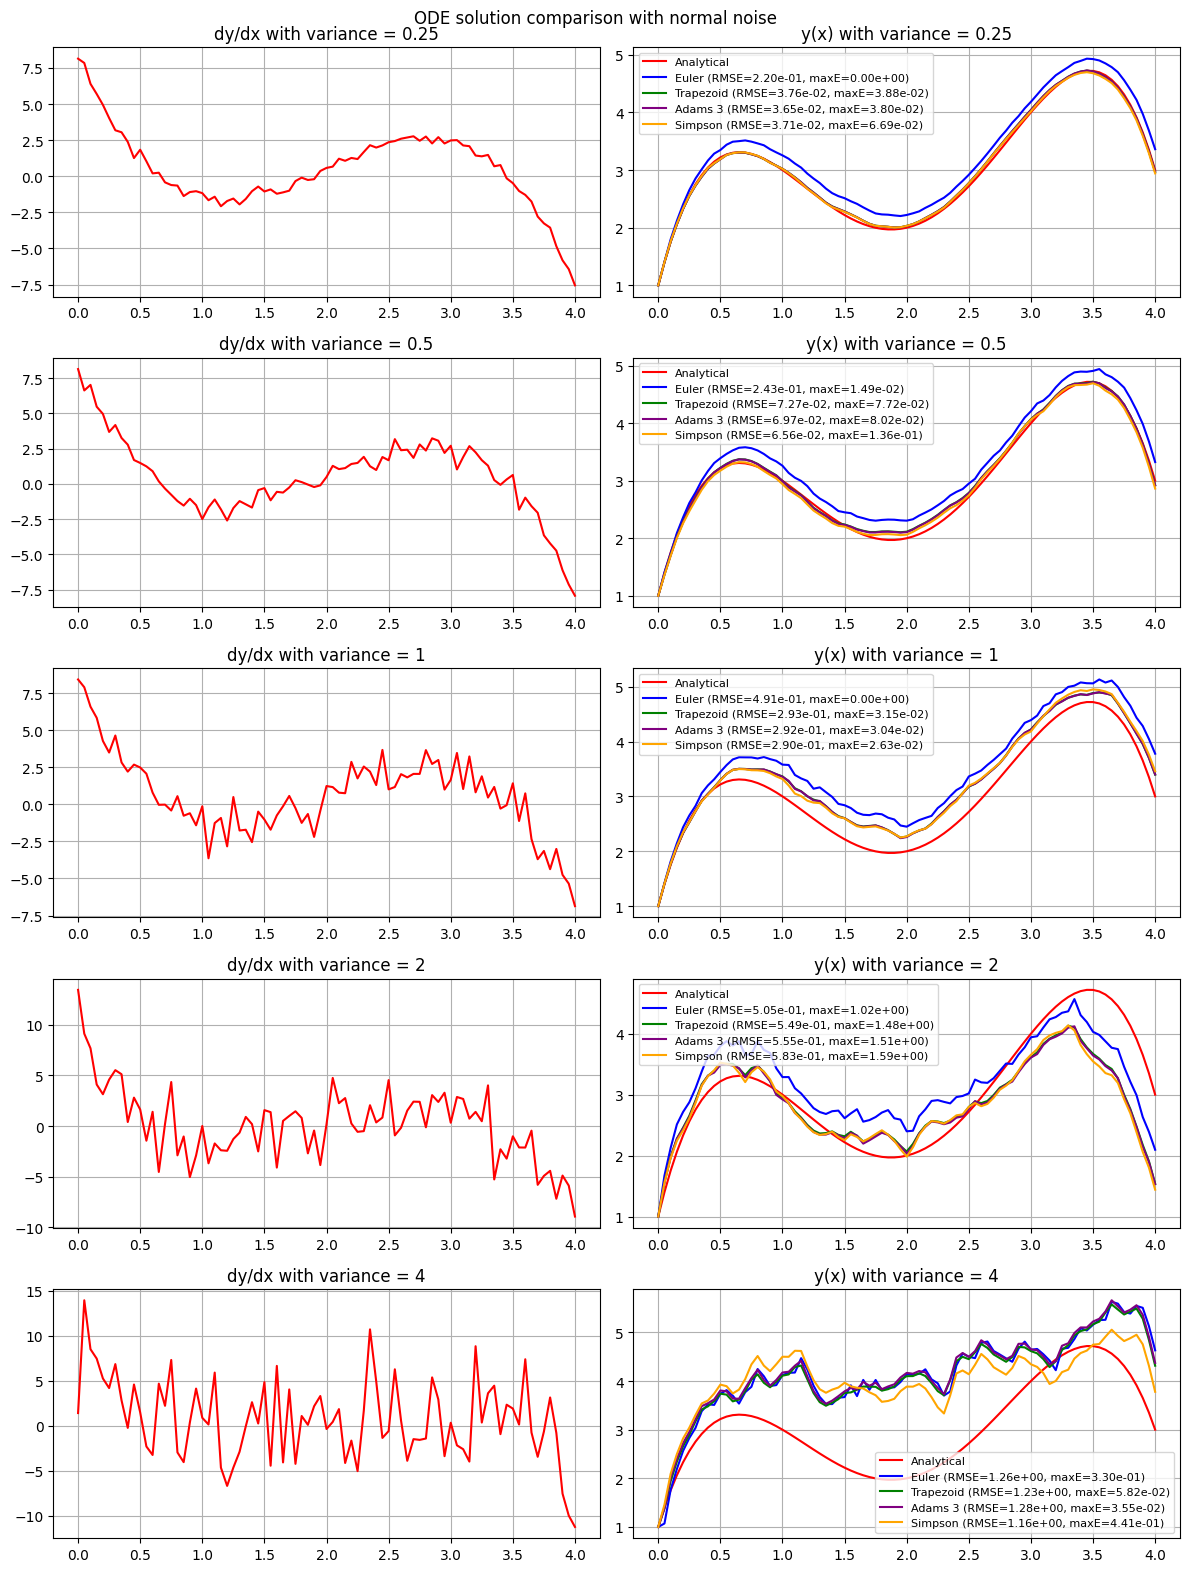

In [3]:
seed = 12345  # Use always the same seed for reproducibility
rng = np.random.default_rng(seed)
vars = [0.25, 0.5, 1, 2, 4]
fig, axes = plt.subplots(len(vars), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with normal noise")
for j, var in enumerate(vars):
    dyBiased = a + stats.norm.rvs(loc=0, scale=var, size=len(a), random_state=rng)
    axes[j, 0].plot(t, dyBiased, color="red")
    axes[j, 0].set_title(f"dy/dx with variance = {var}")
    axes[j, 0].grid()
    plotODESolutions(
        axes[j, 1], f"y(x) with variance = {var}", t, dt, x0, v, dyBiased, y0
    )
fig.tight_layout()
plt.show()

### Bias

Bias is modeled as a constant offset to the signal.

*Conclusion*:

Even small biases can make the integration diverge from the true solution.

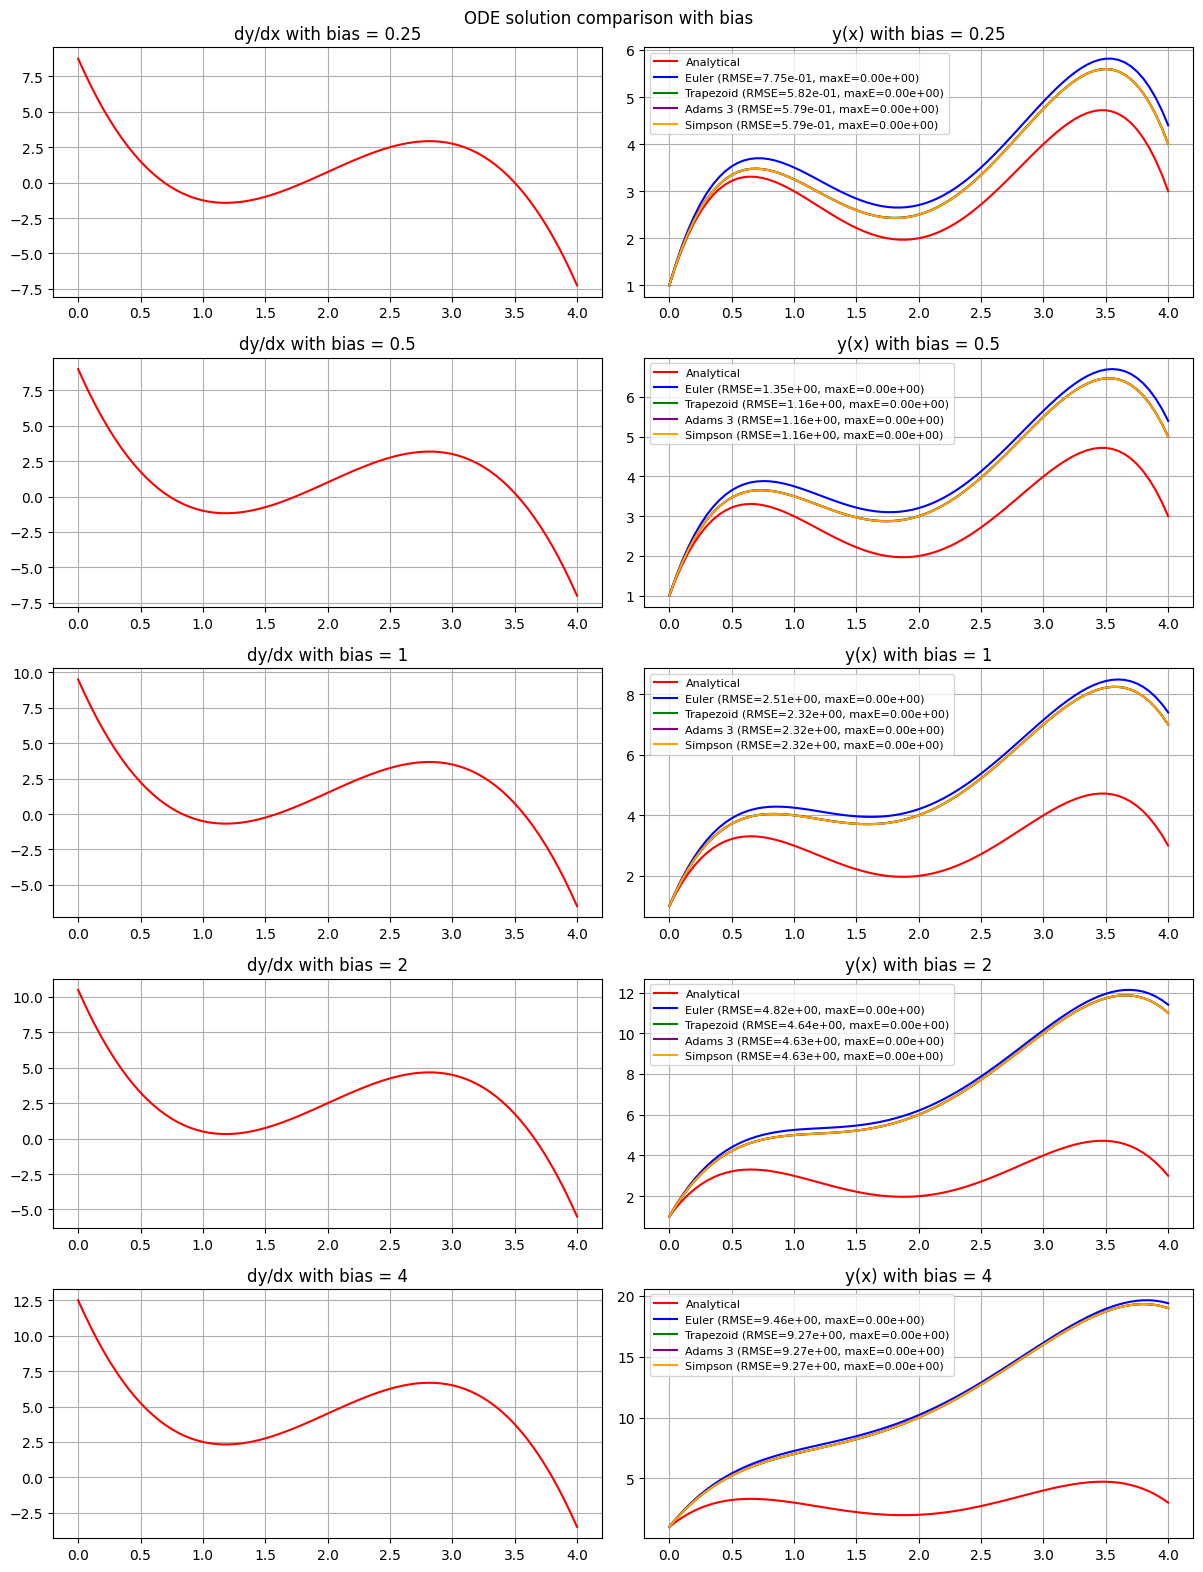

In [4]:
biases = [0.25, 0.5, 1, 2, 4]
fig, axes = plt.subplots(len(biases), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with bias")
for j, bias in enumerate(biases):
    dyBiased = a + bias
    axes[j, 0].plot(t, dyBiased, color="red")
    axes[j, 0].set_title(f"dy/dx with bias = {bias}")
    axes[j, 0].grid()
    plotODESolutions(axes[j, 1], f"y(x) with bias = {bias}", t, dt, x0, v, dyBiased, y0)
fig.tight_layout()
plt.show()

### Drift

Drift is modeled just as a linear function of time with a small slope and bias = 0.

*Conclusion*:

Unless the drift is very small, it will make the integration diverge from the true solution.

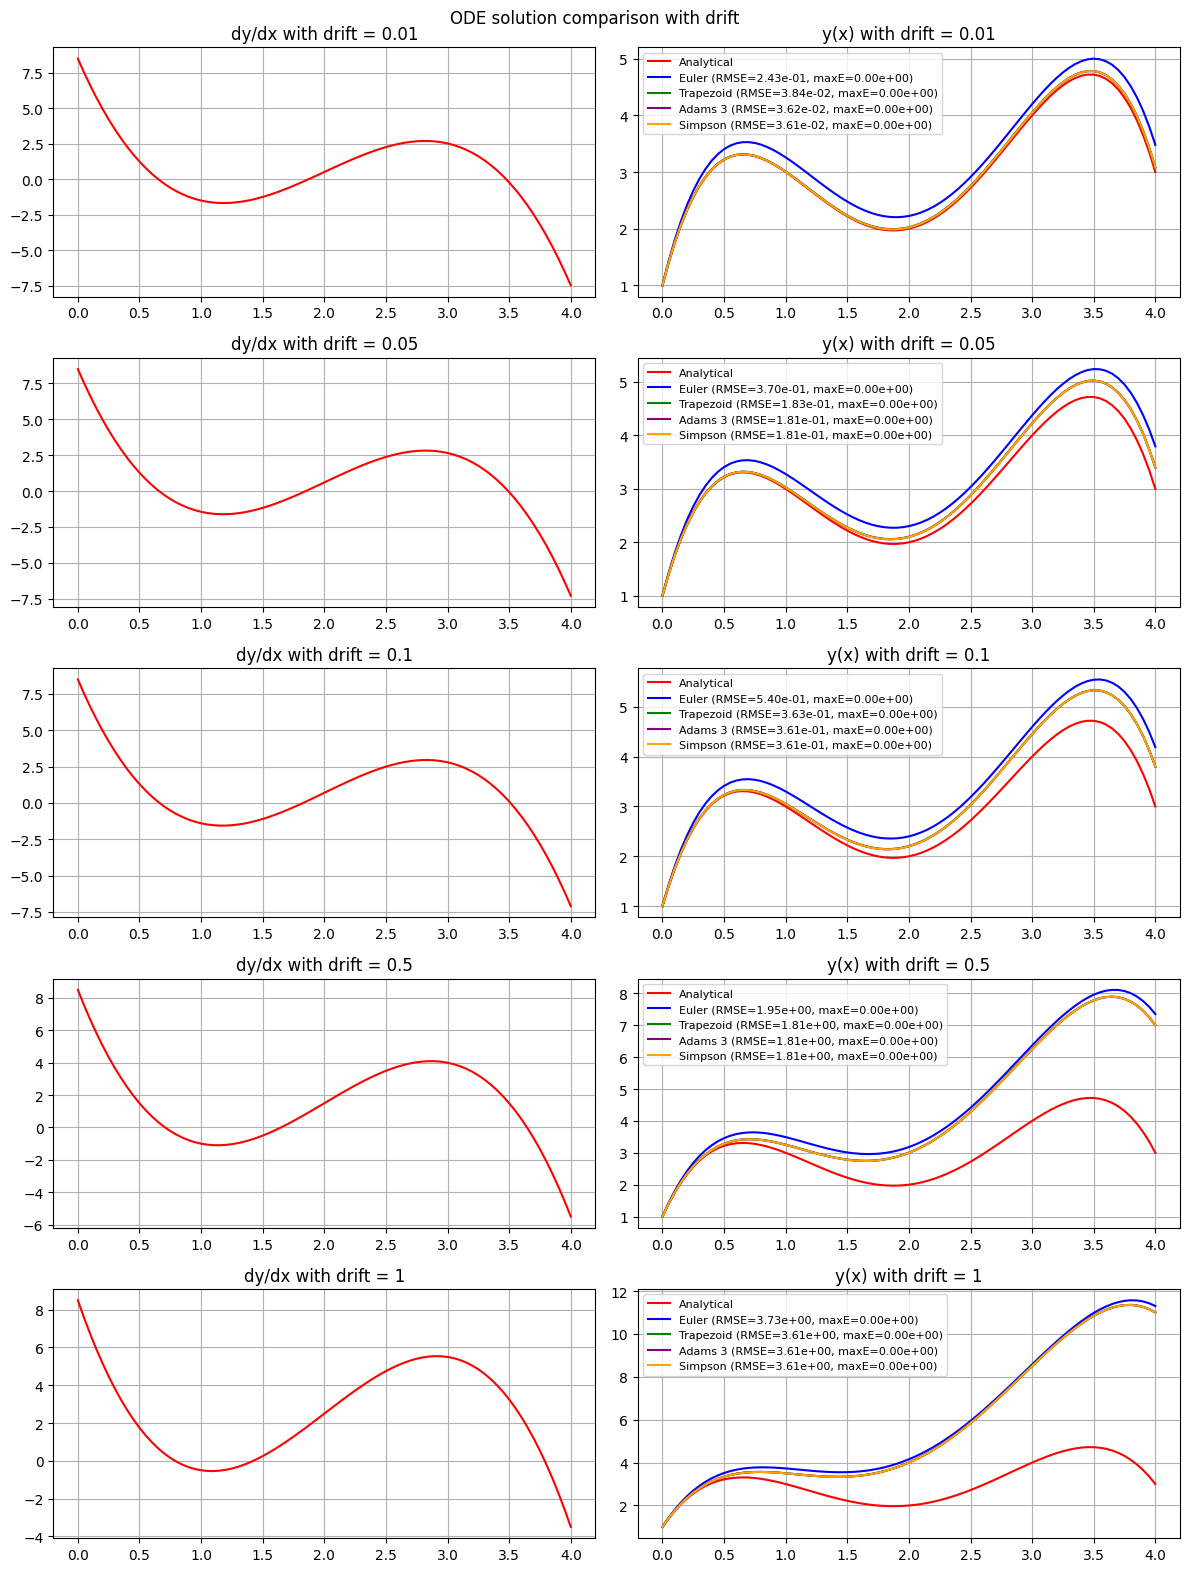

In [5]:
driftSlopes = [0.01, 0.05, 0.1, 0.5, 1]
fig, axes = plt.subplots(len(driftSlopes), 2, figsize=(12, 16))
fig.suptitle("ODE solution comparison with drift")
for j, slope in enumerate(driftSlopes):
    dyDrifted = a + slope * t
    axes[j, 0].plot(t, dyDrifted, color="red")
    axes[j, 0].set_title(f"dy/dx with drift = {slope}")
    axes[j, 0].grid()
    plotODESolutions(
        axes[j, 1], f"y(x) with drift = {slope}", t, dt, x0, v, dyDrifted, y0
    )
fig.tight_layout()
plt.show()

## Real ODEs: stationary + simple rotations captures

During stationary and simple rotations captures, velocity should stay close to zero, as the device is not moving across space. A very simple version of zero-velocity updates (ZUPT) is used to compare it against "raw" integration:

$$
\mathbf{v}_i =
\begin{cases}
\mathbf{0}, & \text{if stationary} \\
\mathbf{v}_{i-1} + \frac{\Delta t}{2}\left(\mathbf{a}_{i-1} + \mathbf{a}_i\right), & \text{otherwise}
\end{cases}
$$

*Conclusion*:

Without some form of ZUPT, velocity will drift away fast (in less than 10-20s) and hard (>1 m/s) from zero even if the device is not moving.

In [6]:
def cumulativeTrapezoidZUPT(a, w, dt):
    v = np.zeros_like(a)
    for i in range(1, len(a)):
        if stationaryChecker.isStationarySample(
            a[i, 0], a[i, 1], a[i, 2], w[i, 0], w[i, 1], w[i, 2], isFiltered=True
        ):
            v[i, :] = 0
        else:
            v[i, :] = v[i - 1, :] + (a[i - 1, :] + a[i, :]) * dt / 2
    return v


def plotSimpleVelocitySeries(captures):
    cols = 3
    rows = len(captures)

    fig, axes = plt.subplots(rows, cols, squeeze=False, figsize=(5 * cols, 4 * rows))
    fig.suptitle(
        "Velocity estimation with trapezoidal integration and simple zero-velocity updates",
        fontsize=16,
    )

    for captureIdx, capture in enumerate(captures):
        seq, a, w, _ = reader.readFiltered(capture)
        t = seq * dt
        v0 = np.array([0.0, 0.0, 0.0])

        vRegular = np.zeros_like(a)
        for j in range(3):
            vRegular[:, j] = v0[j] + integrate.cumulative_trapezoid(
                a[:, j], x=t, dx=dt, initial=0
            )
        vZUPT = v0 + cumulativeTrapezoidZUPT(a, w, dt)

        stationaryIntervals = stationaryChecker.findStationaryIntervals(
            seq, a, w, areFiltered=True
        )

        axes[captureIdx][1].set_title(f"{capture}")
        for j in range(3):
            axis = axes[captureIdx][j]
            axis.plot(t, vRegular[:, j], label="No ZUPT", color="blue")
            axis.plot(t, vZUPT[:, j], label="ZUPT", color="red")
            axis.set_xlabel("t (s)")
            axis.set_ylabel(f"v{'x' if j == 0 else 'y' if j == 1 else 'z'} (m/s)")
            axis.legend()
            axis.grid()

            for lower, upper in stationaryIntervals:
                axis.axvspan(
                    lower * dt, upper * dt, color="tab:gray", alpha=0.25, zorder=0
                )

    fig.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()

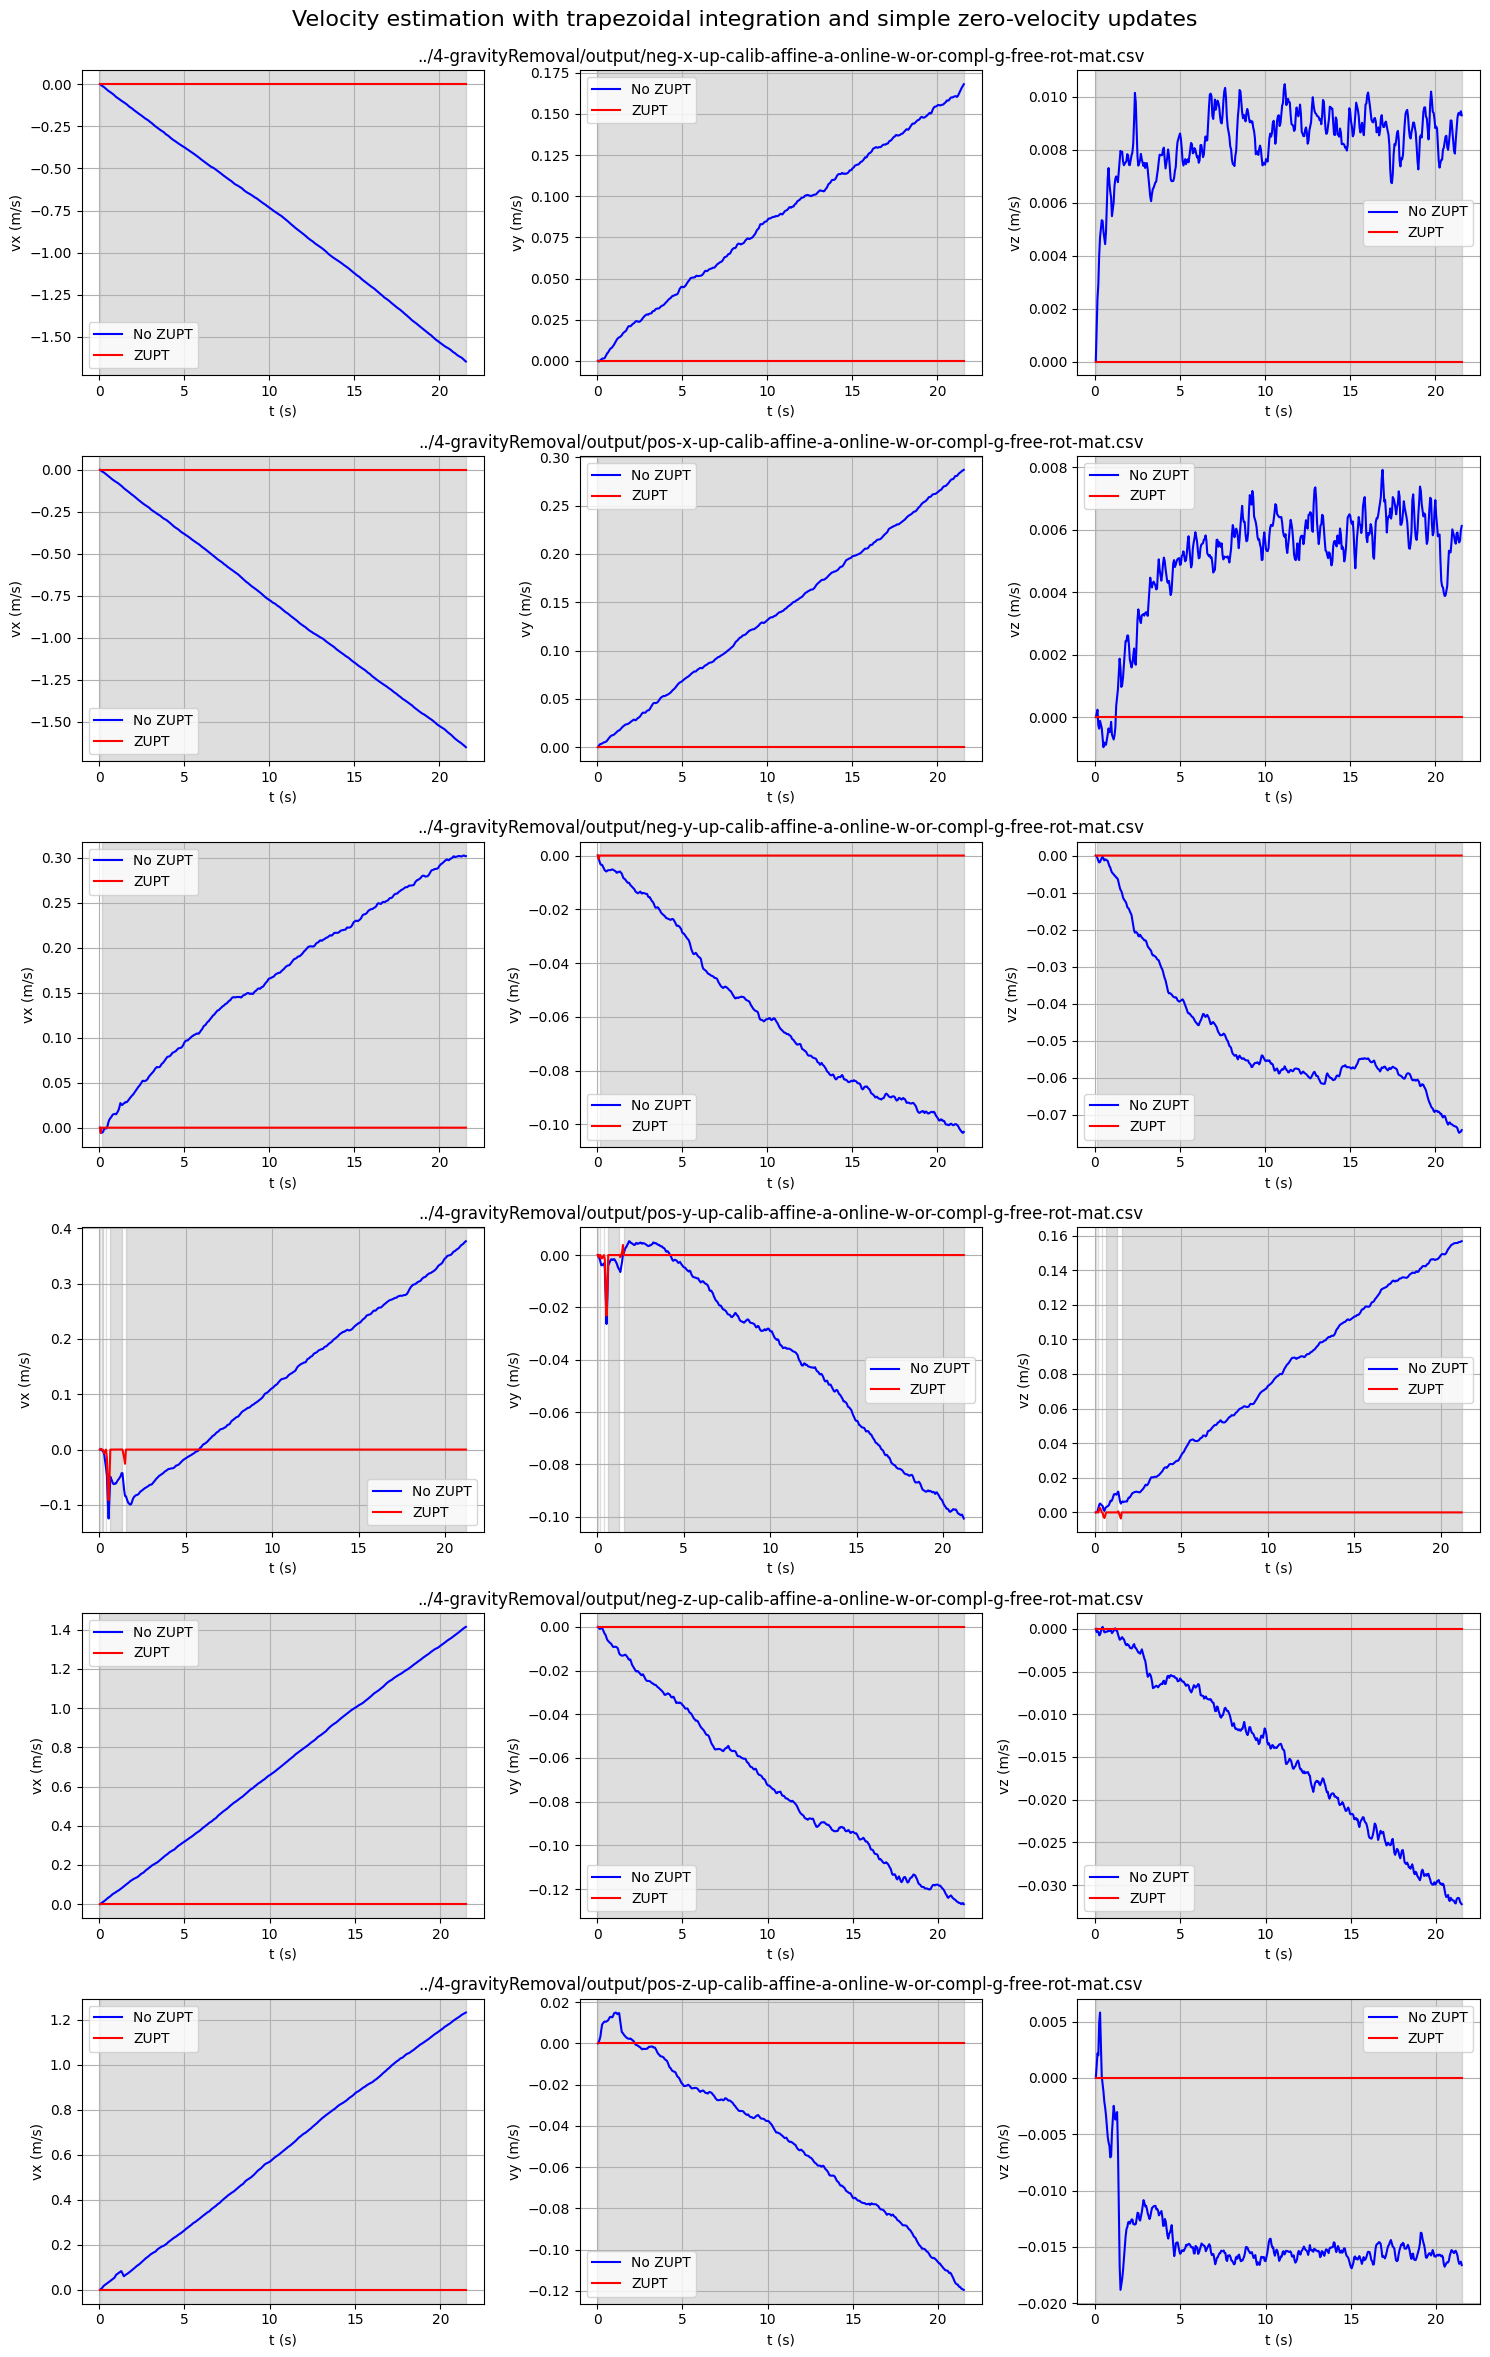

In [7]:
plotSimpleVelocitySeries(stationaryCaptures)

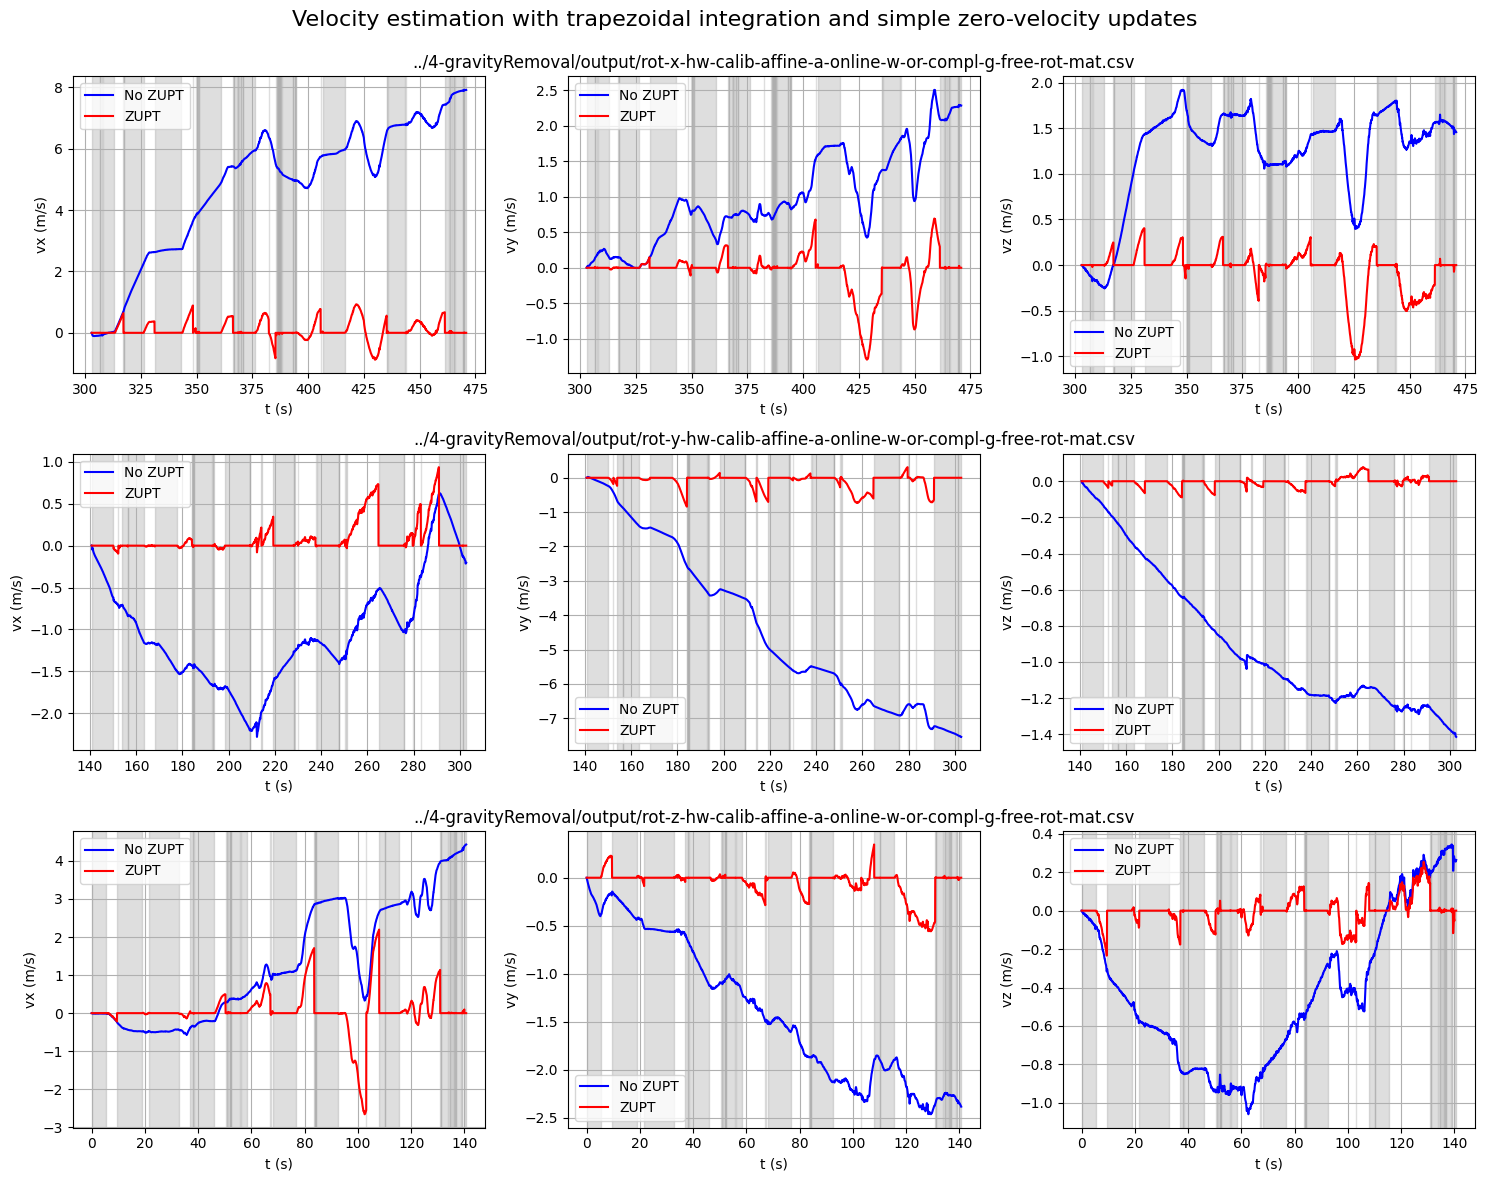

In [8]:
plotSimpleVelocitySeries(simpleRotationsCaptures)

## Real ODEs: real captures

The velocity estimation is much more strained. Real exercise sets last between 30s and 1min, and there aren't as many stationary intervals. In many cases:
* Both the ZUPT and non-ZUPT versions resemble each other.
* Very sharp, step-like changes in velocity are observed due to the ZUPT. This is not physically realistic since it would represent an acceleration that tends to infinity.
* There are upward or downward trends.
* Unrealistic values are observed (e.g. >10 m/s = 36 km/h).

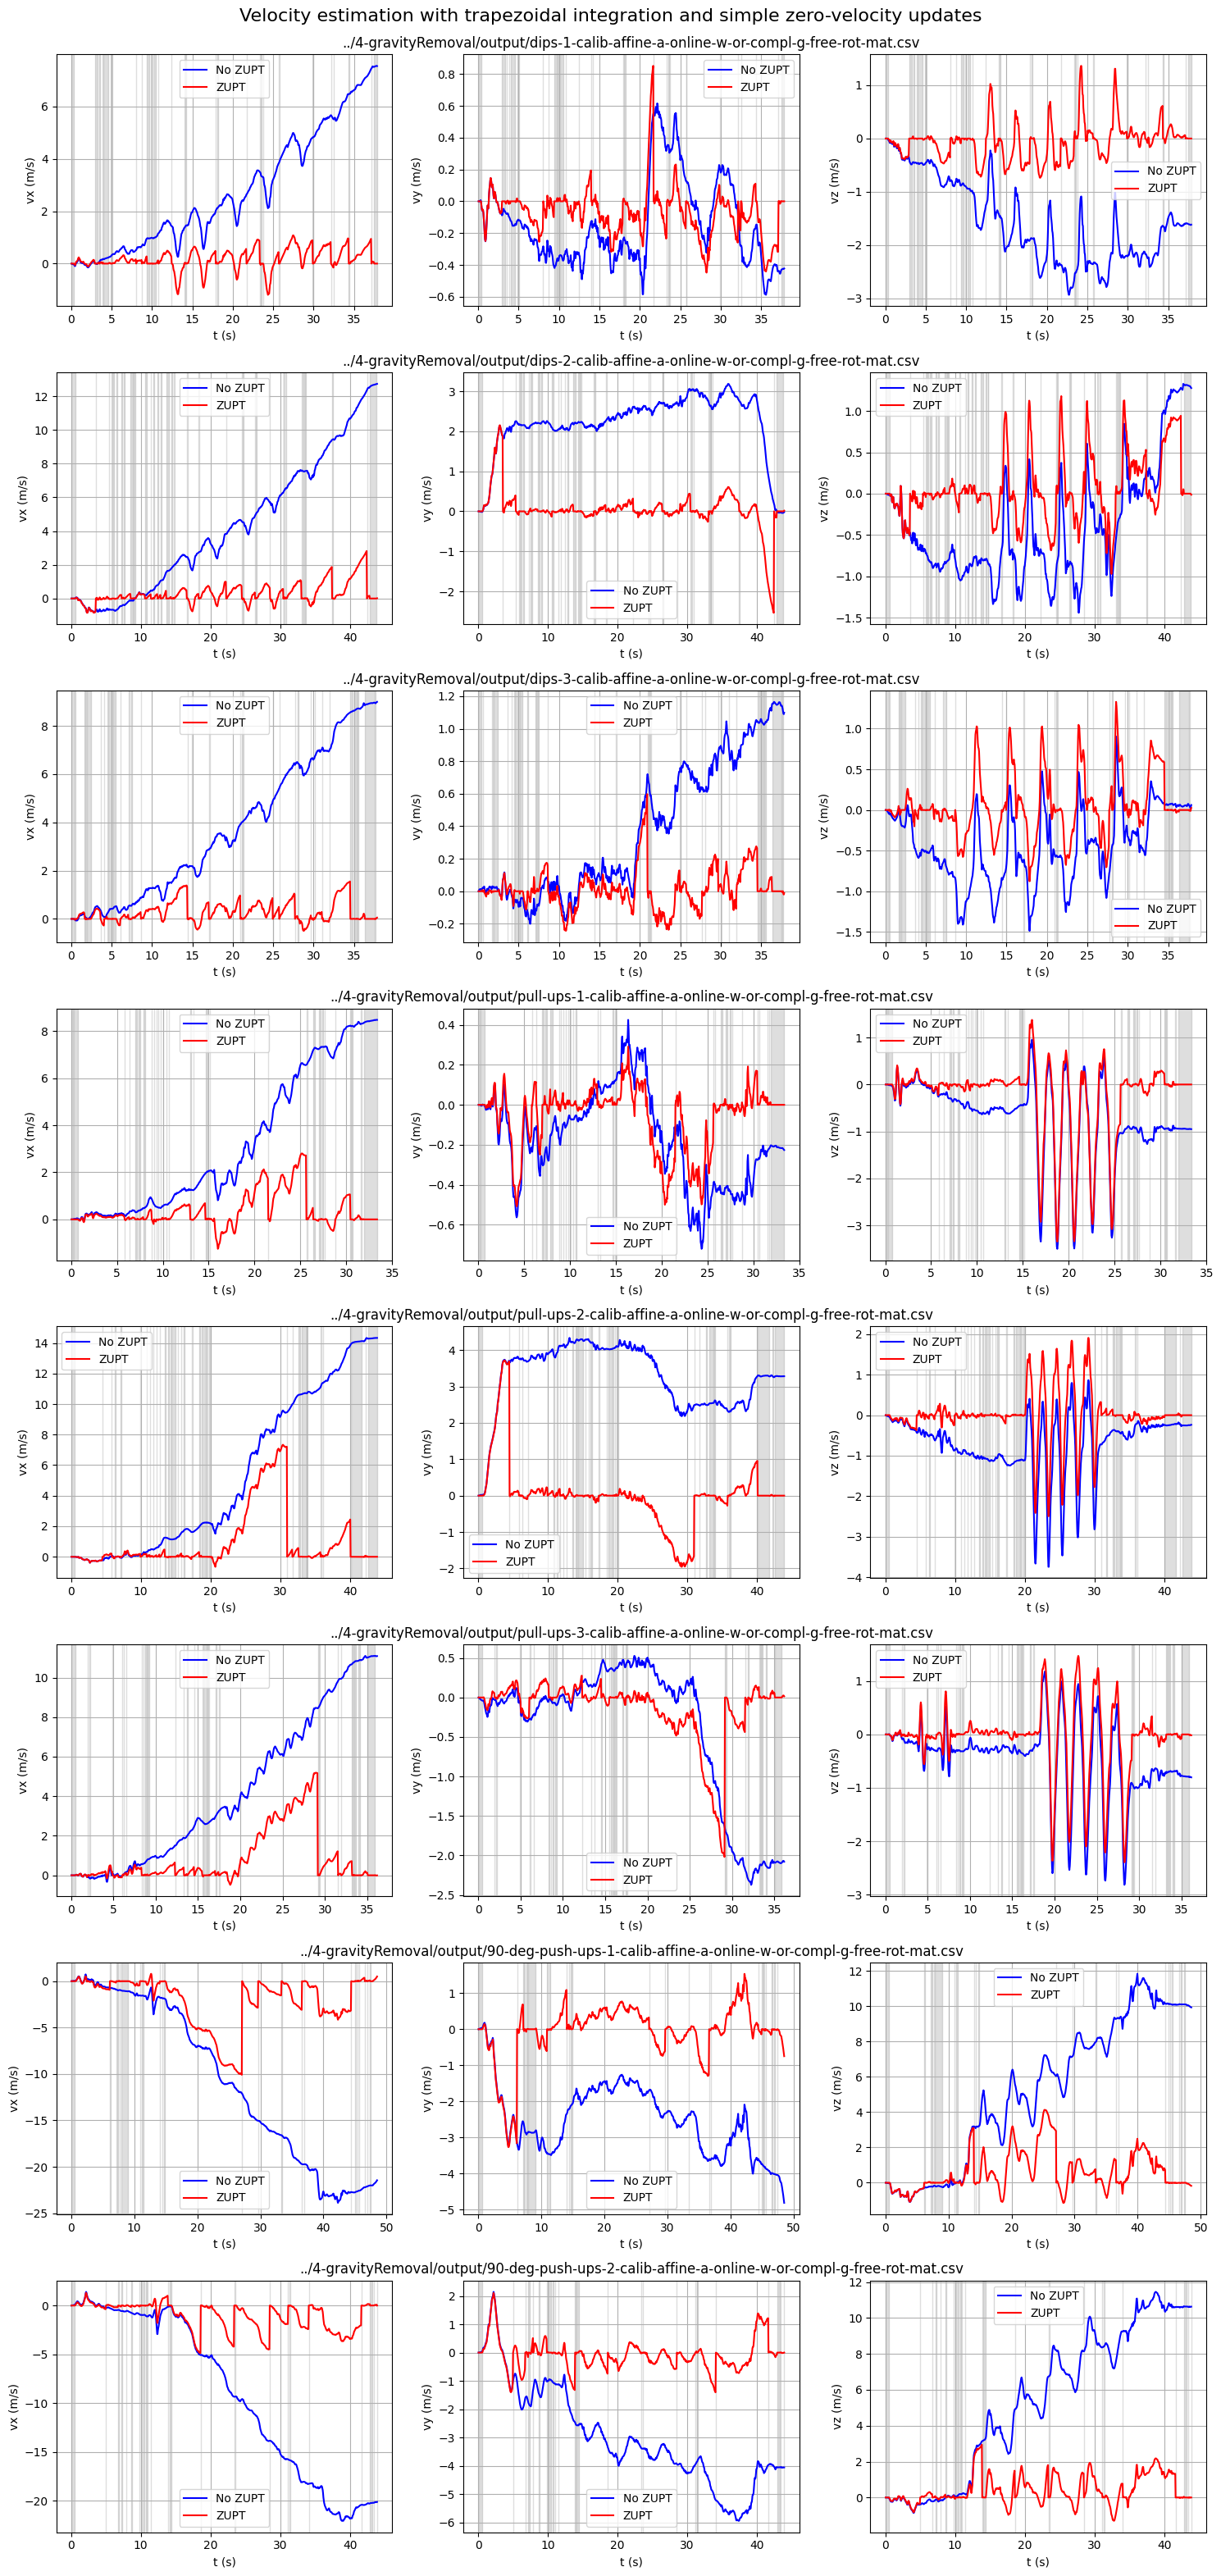

In [9]:
plotSimpleVelocitySeries(exerciseCaptures)

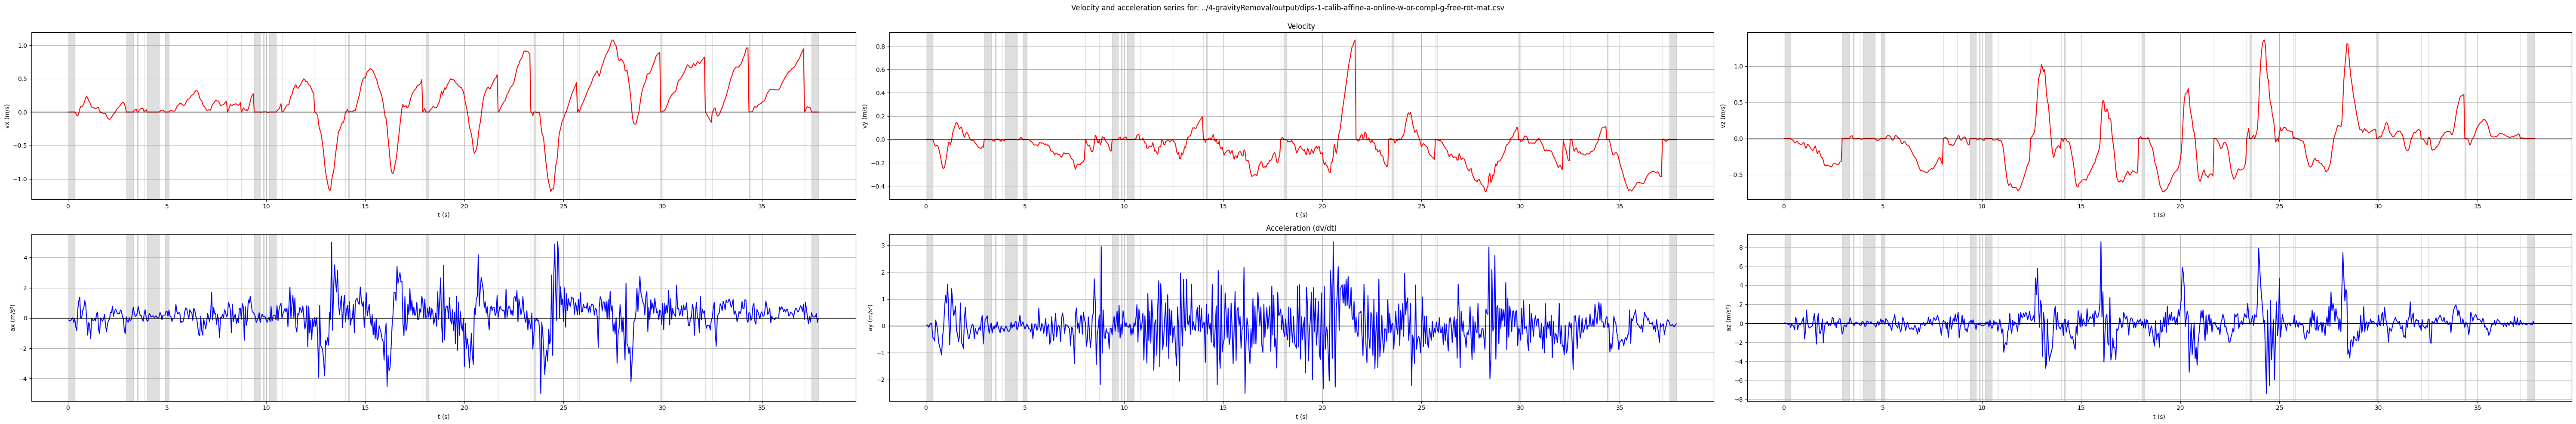

In [10]:
CHOSEN_CAPTURE = exerciseCaptures[0]


def plotVelocityAndAccelerationSeries(capture):
    fig, axes = plt.subplots(2, 3, figsize=(60, 10))
    fig.suptitle(
        f"Velocity and acceleration series for: {capture}",
    )
    seq, a, w, _ = reader.readFiltered(capture)
    t = seq * dt
    v0 = np.array([0.0, 0.0, 0.0])
    v = v0 + cumulativeTrapezoidZUPT(a, w, dt)

    stationaryIntervals = stationaryChecker.findStationaryIntervals(
        seq, a, w, areFiltered=True
    )

    axes[0, 1].set_title(f"Velocity")
    axes[1, 1].set_title(f"Acceleration (dv/dt)")
    for j in range(3):
        axes[0, j].plot(t, v[:, j], color="red")
        axes[0, j].set_xlabel("t (s)")
        axes[0, j].set_ylabel(f"v{'x' if j == 0 else 'y' if j == 1 else 'z'} (m/s)")
        axes[0, j].grid()
        axes[0, j].axhline(0, color="black", linestyle="-", linewidth=1)

        axes[1, j].plot(t, a[:, j], color="blue")
        axes[1, j].set_xlabel("t (s)")
        axes[1, j].set_ylabel(f"a{'x' if j == 0 else 'y' if j == 1 else 'z'} (m/s²)")
        axes[1, j].grid()
        axes[1, j].axhline(0, color="black", linestyle="-", linewidth=1)

        for lower, upper in stationaryIntervals:
            axes[0, j].axvspan(
                lower * dt, upper * dt, color="tab:gray", alpha=0.25, zorder=0
            )
            axes[1, j].axvspan(
                lower * dt, upper * dt, color="tab:gray", alpha=0.25, zorder=0
            )

    fig.tight_layout(rect=(0, 0, 1, 0.985))
    plt.show()


plotVelocityAndAccelerationSeries(CHOSEN_CAPTURE)

# Conclusion

Velocity estimation is not a simple problem. As of the writing of this conclusion (18/7/2026), the results are not good enough to be used in the gym. Simple interventions will be tried out first: online gyro bias estimation, low-pass filtering for noise reduction on gravity-free acceleration (not before the complementary filter, as it would introduce lag compared to gyro). If these don't work, more complex methods will probably be needed, namely the Kalman filter.  